# Kaggle Energy Anomaly Detection — Single Building

This notebook runs the anomaly detector on **one building_id**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from anomlib.datasets.kaggle_energy.load import load_train
from anomlib.detectors import EnergyTimeSeriesDetector, GenericTimeSeriesDetector, EnergySupervisedDetector
from anomlib.core.schema import normalize_timeseries_df
from anomlib.core.eventing import scores_to_events

In [2]:
# ---- Config ----
DATA_PATH = "../data/kaggle/train.csv"   # relative to benchmarks/ or notebook location
BUILDING_ID = 1068                     
TRAIN_FRAC = 0.8
DETECTOR_TYPE = "unsupervised"  # "supervised" or "unsupervised"
UNSUPERVISED_DETECTOR = "energy"  # "energy" or "generic" (for unsupervised only)

# Unsupervised detector knobs (start with a balanced set; tune later if needed)
DIRECTION = "both"
THRESHOLD = 6.0
THRESHOLD_QUANTILE = 0.9995
THRESHOLD_CAP = 10.0
THRESHOLD_END_RATIO = 0.25
MIN_DURATION = "2h"
GAP_TOLERANCE = "15min"

# Supervised detector knobs
SUPERVISED_THRESHOLD = 0.9
SUPERVISED_THRESHOLD_STRATEGY = "recall_target"
SUPERVISED_RECALL_TARGET = 0.65

In [3]:
# Load dataset
df = load_train(DATA_PATH)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.dropna(subset=["meter_reading"]).reset_index(drop=True)

# Filter to one building
b = df[df["building_id"] == BUILDING_ID].copy().sort_values("timestamp").reset_index(drop=True)
print("rows:", len(b), "  time span:", b["timestamp"].min(), "->", b["timestamp"].max())
b.head()

rows: 8772   time span: 2016-01-01 00:00:00 -> 2016-12-31 23:00:00


,building_id,timestamp,meter_reading,anomaly
0,1068,2016-01-01 00:00:00,58.538,0
1,1068,2016-01-01 01:00:00,58.485,0
2,1068,2016-01-01 02:00:00,59.220,0
3,1068,2016-01-01 03:00:00,57.825,0
4,1068,2016-01-01 04:00:00,58.282,0


In [4]:
def time_split(df_in: pd.DataFrame, frac: float) -> tuple[pd.DataFrame, pd.DataFrame]:
    df_in = df_in.sort_values("timestamp").reset_index(drop=True)
    k = int(len(df_in) * frac)
    return df_in.iloc[:k].copy(), df_in.iloc[k:].copy()

train_b, test_b = time_split(b, TRAIN_FRAC)
print("train rows:", len(train_b), "test rows:", len(test_b))

train rows: 7017 test rows: 1755


In [5]:
# Select detector and prepare fit data
if DETECTOR_TYPE == "supervised":
    if "anomaly" not in train_b.columns:
        raise ValueError("Supervised detector requires 'anomaly' column in training data.")
    Detector = EnergySupervisedDetector
    fit_b = train_b.copy()  # use full train with labels
    print("fit rows (supervised, all train):", len(fit_b))
    det = Detector(
        entity_col="building_id",
        time_col="timestamp",
        value_col="meter_reading",
        threshold=SUPERVISED_THRESHOLD,
        threshold_strategy=SUPERVISED_THRESHOLD_STRATEGY,
        recall_target=SUPERVISED_RECALL_TARGET,
    )
else:  # unsupervised
    if "anomaly" in train_b.columns:
        fit_b = train_b[train_b["anomaly"] == 0].copy()
        print("fit rows (normal-only):", len(fit_b), "/", len(train_b))
    else:
        fit_b = train_b.copy()
        print("fit rows (all train):", len(fit_b))
    if UNSUPERVISED_DETECTOR == "energy":
        Detector = EnergyTimeSeriesDetector
    else:
        Detector = GenericTimeSeriesDetector
    det = Detector(
        entity_col="building_id",
        time_col="timestamp",
        value_col="meter_reading",
        direction=DIRECTION,
        threshold=THRESHOLD,
        threshold_quantile=THRESHOLD_QUANTILE,
        threshold_cap=THRESHOLD_CAP,
        threshold_end_ratio=THRESHOLD_END_RATIO,
        min_duration=MIN_DURATION,
        gap_tolerance=GAP_TOLERANCE,
    )

det.fit(fit_b)
events, scores = det.detect(test_b)
print("events:", len(events))
events[:3]

fit rows (normal-only): 6756 / 7017
events: 2


[Event(entity_id=1068, start=Timestamp('2016-11-02 09:00:00'), end=Timestamp('2016-11-02 21:00:00'), direction='both', severity=9.924026419168143, score_peak=9.924026419168143, score_mean=8.559420516240088, reason='both deviation beyond 9.220783337464363 (end_ratio=0.25)'),
 Event(entity_id=1068, start=Timestamp('2016-12-02 09:00:00'), end=Timestamp('2016-12-02 21:00:00'), direction='both', severity=9.660730600812728, score_peak=9.660730600812728, score_mean=8.197404764674728, reason='both deviation beyond 9.220783337464363 (end_ratio=0.25)')]

In [6]:
# Attach score to test rows
df_eval = test_b.copy().reset_index(drop=True)

if isinstance(scores, pd.DataFrame) and "score" in scores.columns:
    df_eval["score"] = scores["score"].to_numpy()
elif isinstance(scores, pd.Series):
    df_eval["score"] = scores.to_numpy()
else:
    df_eval["score"] = np.asarray(scores)

df_eval.head()

,building_id,timestamp,meter_reading,anomaly,score
0,1068,2016-10-19 19:00:00,135.105,0,2.427285
1,1068,2016-10-19 20:00:00,118.493,0,1.776177
2,1068,2016-10-19 21:00:00,85.838,0,0.803488
3,1068,2016-10-19 22:00:00,68.060,0,-0.103408
4,1068,2016-10-19 23:00:00,64.990,0,-0.069203


In [7]:
# Convert event intervals -> pointwise predictions for this building
def label_points_from_events_single(df_in: pd.DataFrame, events) -> np.ndarray:
    if not events:
        return np.zeros(len(df_in), dtype=np.int8)
    intervals = [(pd.to_datetime(e.start), pd.to_datetime(e.end)) for e in events]
    intervals.sort(key=lambda x: x[0])

    t = df_in["timestamp"].to_numpy()
    j = 0
    m = np.zeros(len(df_in), dtype=np.int8)
    for i in range(len(df_in)):
        ti = t[i]
        while j < len(intervals) and intervals[j][1] < ti:
            j += 1
        if j < len(intervals):
            s, e = intervals[j]
            if s <= ti <= e:
                m[i] = 1
    return m

df_eval["pred"] = label_points_from_events_single(df_eval, events)
df_eval["pred"].value_counts()

pred
0    1729
1      26
Name: count, dtype: int64

In [ ]:
# Pointwise metrics for this building (if labels exist)
if "anomaly" in df_eval.columns:
    tp = int(((df_eval["pred"] == 1) & (df_eval["anomaly"] == 1)).sum())
    fp = int(((df_eval["pred"] == 1) & (df_eval["anomaly"] == 0)).sum())
    fn = int(((df_eval["pred"] == 0) & (df_eval["anomaly"] == 1)).sum())
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    print("tp fp fn:", tp, fp, fn)
    print(f"precision={precision:.3f}  recall={recall:.3f}  f1={f1:.3f}")
else:
    print("No anomaly labels in data — skipping metrics.")

In [ ]:
# Visualize: meter_reading + score + shaded predicted events
def plot_building(df_in: pd.DataFrame, events):
    fig = plt.figure(figsize=(14, 7))
    ax1 = plt.gca()
    ax1.plot(df_in["timestamp"], df_in["meter_reading"], linewidth=1)
    ax1.set_title(f"Building {BUILDING_ID} — meter_reading (test split)")
    ax1.set_xlabel("timestamp")
    ax1.set_ylabel("meter_reading")

    # shade predicted events
    for e in events:
        ax1.axvspan(pd.to_datetime(e.start), pd.to_datetime(e.end), alpha=0.15)

    plt.show()

    fig = plt.figure(figsize=(14, 5))
    ax2 = plt.gca()
    ax2.plot(df_in["timestamp"], df_in["score"], linewidth=1)
    ax2.set_title(f"Building {BUILDING_ID} — anomaly score (test split)")
    ax2.set_xlabel("timestamp")
    ax2.set_ylabel("score")
    for e in events:
        ax2.axvspan(pd.to_datetime(e.start), pd.to_datetime(e.end), alpha=0.15)
    plt.show()

plot_building(df_eval, events)

In [ ]:
# Inspect events table (start/end/peak score if available)
def events_table(events):
    rows=[]
    for i,e in enumerate(events):
        rows.append({
            "event_idx": i,
            "start": pd.to_datetime(e.start),
            "end": pd.to_datetime(e.end),
            "direction": getattr(e, "direction", None),
            "score_peak": getattr(e, "score_peak", np.nan),
            "score_mean": getattr(e, "score_mean", np.nan),
            "severity": getattr(e, "severity", np.nan),
            "reason": getattr(e, "reason", ""),
        })
    return pd.DataFrame(rows)

evt_df = events_table(events)
evt_df.head(20)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from anomlib.datasets.kaggle_energy.load import load_train
from anomlib.detectors import EnergyTimeSeriesDetector, GenericTimeSeriesDetector, EnergySupervisedDetector
from anomlib.core.schema import normalize_timeseries_df
from anomlib.core.eventing import scores_to_events


In [2]:
# ---- Config ----
DATA_PATH = "../data/kaggle/train.csv"   # relative to benchmarks/ or notebook location
BUILDING_ID = 1068                     
TRAIN_FRAC = 0.8
DETECTOR_TYPE = "unsupervised"  # "supervised" or "unsupervised"
UNSUPERVISED_DETECTOR = "energy"  # "energy" or "generic" (for unsupervised only)

# Unsupervised detector knobs (start with a balanced set; tune later if needed)
DIRECTION = "both"
THRESHOLD = 6.0
THRESHOLD_QUANTILE = 0.9995
THRESHOLD_CAP = 10.0
THRESHOLD_END_RATIO = 0.25
MIN_DURATION = "2h"
GAP_TOLERANCE = "15min"

# Supervised detector knobs
SUPERVISED_THRESHOLD = 0.9
SUPERVISED_THRESHOLD_STRATEGY = "recall_target"
SUPERVISED_RECALL_TARGET = 0.65


In [3]:
# Load dataset
df = load_train(DATA_PATH)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.dropna(subset=["meter_reading"]).reset_index(drop=True)

# Filter to one building
b = df[df["building_id"] == BUILDING_ID].copy().sort_values("timestamp").reset_index(drop=True)
print("rows:", len(b), "  time span:", b["timestamp"].min(), "->", b["timestamp"].max())
b.head()


rows: 8772   time span: 2016-01-01 00:00:00 -> 2016-12-31 23:00:00


,building_id,timestamp,meter_reading,anomaly
0,1068,2016-01-01 00:00:00,58.538,0
1,1068,2016-01-01 01:00:00,58.485,0
2,1068,2016-01-01 02:00:00,59.220,0
3,1068,2016-01-01 03:00:00,57.825,0
4,1068,2016-01-01 04:00:00,58.282,0


In [4]:
def time_split(df_in: pd.DataFrame, frac: float) -> tuple[pd.DataFrame, pd.DataFrame]:
    df_in = df_in.sort_values("timestamp").reset_index(drop=True)
    k = int(len(df_in) * frac)
    return df_in.iloc[:k].copy(), df_in.iloc[k:].copy()

train_b, test_b = time_split(b, TRAIN_FRAC)
print("train rows:", len(train_b), "test rows:", len(test_b))


train rows: 7017 test rows: 1755


In [5]:
# Select detector and prepare fit data
if DETECTOR_TYPE == "supervised":
    if "anomaly" not in train_b.columns:
        raise ValueError("Supervised detector requires 'anomaly' column in training data.")
    Detector = EnergySupervisedDetector
    fit_b = train_b.copy()  # use full train with labels
    print("fit rows (supervised, all train):", len(fit_b))
    det = Detector(
        entity_col="building_id",
        time_col="timestamp",
        value_col="meter_reading",
        threshold=SUPERVISED_THRESHOLD,
        threshold_strategy=SUPERVISED_THRESHOLD_STRATEGY,
        recall_target=SUPERVISED_RECALL_TARGET,
    )
else:  # unsupervised
    if "anomaly" in train_b.columns:
        fit_b = train_b[train_b["anomaly"] == 0].copy()
        print("fit rows (normal-only):", len(fit_b), "/", len(train_b))
    else:
        fit_b = train_b.copy()
        print("fit rows (all train):", len(fit_b))
    if UNSUPERVISED_DETECTOR == "energy":
        Detector = EnergyTimeSeriesDetector
    else:
        Detector = GenericTimeSeriesDetector
    det = Detector(
        entity_col="building_id",
        time_col="timestamp",
        value_col="meter_reading",
        direction=DIRECTION,
        threshold=THRESHOLD,
        threshold_quantile=THRESHOLD_QUANTILE,
        threshold_cap=THRESHOLD_CAP,
        threshold_end_ratio=THRESHOLD_END_RATIO,
        min_duration=MIN_DURATION,
        gap_tolerance=GAP_TOLERANCE,
    )

det.fit(fit_b)
events, scores = det.detect(test_b)
print("events:", len(events))
events[:3]


fit rows (normal-only): 6756 / 7017
events: 2


[Event(entity_id=1068, start=Timestamp('2016-11-02 09:00:00'), end=Timestamp('2016-11-02 21:00:00'), direction='both', severity=9.924026419168143, score_peak=9.924026419168143, score_mean=8.559420516240088, reason='both deviation beyond 9.220783337464363 (end_ratio=0.25)'),
 Event(entity_id=1068, start=Timestamp('2016-12-02 09:00:00'), end=Timestamp('2016-12-02 21:00:00'), direction='both', severity=9.660730600812728, score_peak=9.660730600812728, score_mean=8.197404764674728, reason='both deviation beyond 9.220783337464363 (end_ratio=0.25)')]

In [6]:
# Attach score to test rows
df_eval = test_b.copy().reset_index(drop=True)

if isinstance(scores, pd.DataFrame) and "score" in scores.columns:
    df_eval["score"] = scores["score"].to_numpy()
elif isinstance(scores, pd.Series):
    df_eval["score"] = scores.to_numpy()
else:
    df_eval["score"] = np.asarray(scores)

df_eval.head()


,building_id,timestamp,meter_reading,anomaly,score
0,1068,2016-10-19 19:00:00,135.105,0,2.427285
1,1068,2016-10-19 20:00:00,118.493,0,1.776177
2,1068,2016-10-19 21:00:00,85.838,0,0.803488
3,1068,2016-10-19 22:00:00,68.060,0,-0.103408
4,1068,2016-10-19 23:00:00,64.990,0,-0.069203


In [7]:
# Convert event intervals -> pointwise predictions for this building
def label_points_from_events_single(df_in: pd.DataFrame, events) -> np.ndarray:
    if not events:
        return np.zeros(len(df_in), dtype=np.int8)
    intervals = [(pd.to_datetime(e.start), pd.to_datetime(e.end)) for e in events]
    intervals.sort(key=lambda x: x[0])

    t = df_in["timestamp"].to_numpy()
    j = 0
    m = np.zeros(len(df_in), dtype=np.int8)
    for i in range(len(df_in)):
        ti = t[i]
        while j < len(intervals) and intervals[j][1] < ti:
            j += 1
        if j < len(intervals):
            s, e = intervals[j]
            if s <= ti <= e:
                m[i] = 1
    return m

df_eval["pred"] = label_points_from_events_single(df_eval, events)
df_eval["pred"].value_counts()


pred
0    1729
1      26
Name: count, dtype: int64

In [ ]:
# Create true events from labels for visualization
if "anomaly" in df_eval.columns:
    true_events = scores_to_events(
        df=df_eval,
        score_col="anomaly",
        entity_col="building_id",
        time_col="timestamp",
        direction="high",
        threshold=0.5,
        min_duration="1h",
        gap_tolerance="1h",
    )
else:
    true_events = []
<VSCode.Cell id="#VSC-54caf2b2" language="python" >
# Pointwise metrics for this building (if labels exist)
if "anomaly" in df_eval.columns:
    tp = int(((df_eval["pred"] == 1) & (df_eval["anomaly"] == 1)).sum())
    fp = int(((df_eval["pred"] == 1) & (df_eval["anomaly"] == 0)).sum())
    fn = int(((df_eval["pred"] == 0) & (df_eval["anomaly"] == 1)).sum())
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    print("tp fp fn:", tp, fp, fn)
    print(f"precision={precision:.3f}  recall={recall:.3f}  f1={f1:.3f}")
else:
    print("No anomaly labels in data — skipping metrics.")


SyntaxError: invalid syntax (1157119116.py, line 15)

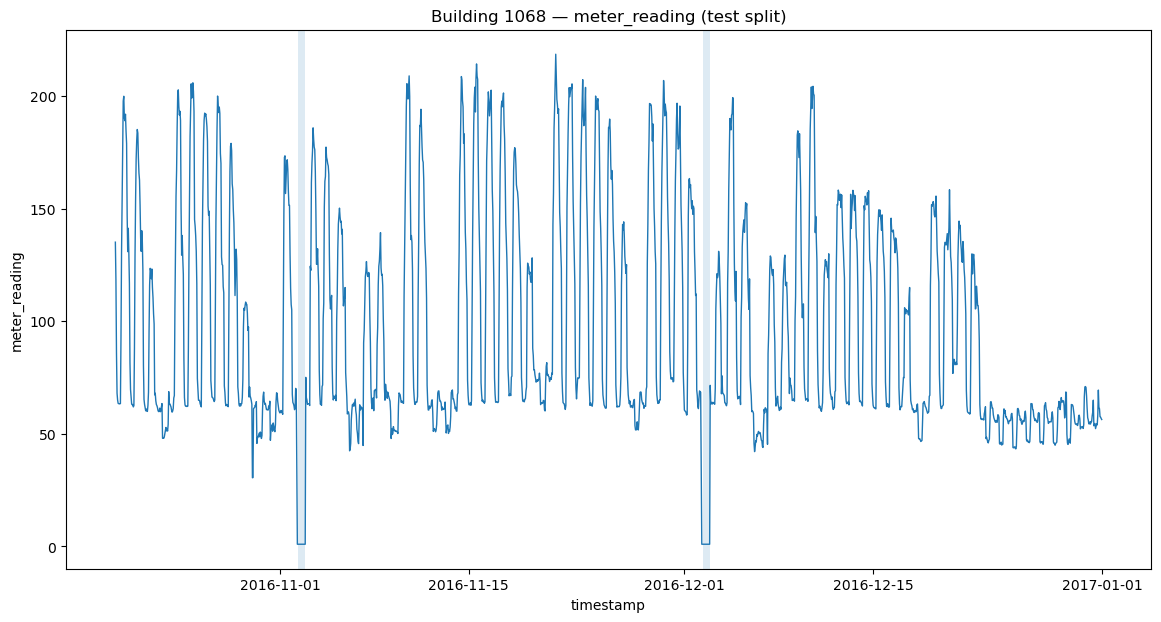

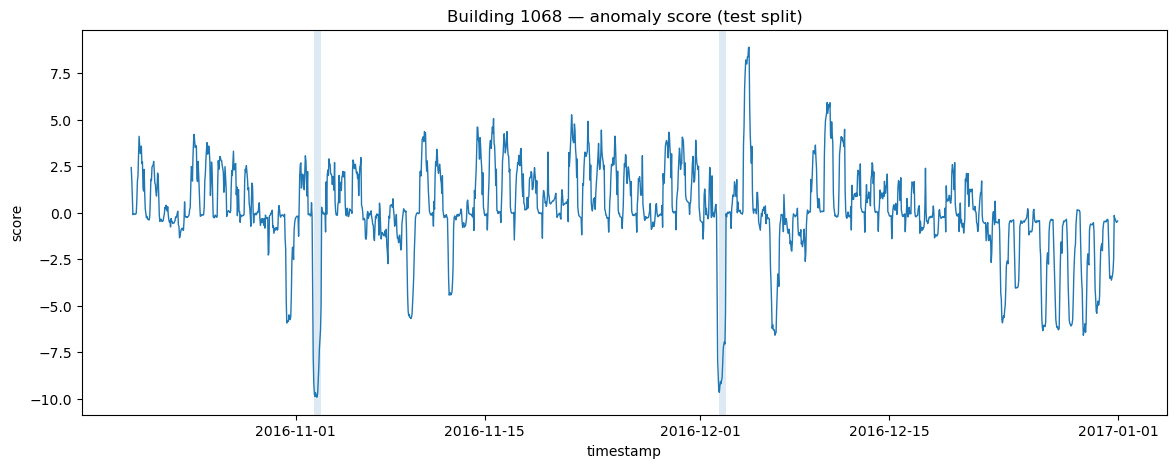

In [ ]:
# Visualize: meter_reading + score + shaded predicted events
def plot_building(df_in: pd.DataFrame, events, true_events=None):
    fig = plt.figure(figsize=(14, 7))
    ax1 = plt.gca()
    ax1.plot(df_in["timestamp"], df_in["meter_reading"], linewidth=1)
    ax1.set_title(f"Building {BUILDING_ID} — meter_reading (test split)")
    ax1.set_xlabel("timestamp")
    ax1.set_ylabel("meter_reading")

    # shade predicted events
    for e in events:
        ax1.axvspan(pd.to_datetime(e.start), pd.to_datetime(e.end), alpha=0.15, label='Predicted' if e == events[0] else "")

    # shade true events
    if true_events:
        for e in true_events:
            ax1.axvspan(pd.to_datetime(e.start), pd.to_datetime(e.end), color='red', alpha=0.1, label='True Anomaly' if e == true_events[0] else "")

    ax1.legend()
    plt.show()

    fig = plt.figure(figsize=(14, 5))
    ax2 = plt.gca()
    ax2.plot(df_in["timestamp"], df_in["score"], linewidth=1)
    ax2.set_title(f"Building {BUILDING_ID} — anomaly score (test split)")
    ax2.set_xlabel("timestamp")
    ax2.set_ylabel("score")
    for e in events:
        ax2.axvspan(pd.to_datetime(e.start), pd.to_datetime(e.end), alpha=0.15)
    if true_events:
        for e in true_events:
            ax2.axvspan(pd.to_datetime(e.start), pd.to_datetime(e.end), color='red', alpha=0.1)
    plt.show()

plot_building(df_eval, events, true_events)


In [10]:
# Inspect events table (start/end/peak score if available)
def events_table(events):
    rows=[]
    for i,e in enumerate(events):
        rows.append({
            "event_idx": i,
            "start": pd.to_datetime(e.start),
            "end": pd.to_datetime(e.end),
            "direction": getattr(e, "direction", None),
            "score_peak": getattr(e, "score_peak", np.nan),
            "score_mean": getattr(e, "score_mean", np.nan),
            "severity": getattr(e, "severity", np.nan),
            "reason": getattr(e, "reason", ""),
        })
    return pd.DataFrame(rows)

evt_df = events_table(events)
evt_df.head(20)


,event_idx,start,end,direction,score_peak,score_mean,severity,reason
0,0,2016-11-02 09:00:00,2016-11-02 21:00:00,both,9.924026,8.559421,9.924026,both deviation beyond 9.220783337464363 (end_r...
1,1,2016-12-02 09:00:00,2016-12-02 21:00:00,both,9.660731,8.197405,9.660731,both deviation beyond 9.220783337464363 (end_r...
